# CheXNet — Fixed Arbiter for Counterfactual Evaluation

Downloads the arnoweng/CheXNet checkpoint (DenseNet-121 pretrained on ChestX-ray14),
loads it, and verifies inference on a test image.

This model is **never fine-tuned** — it acts as a fixed oracle to measure:
- **Flip rate**: fraction of counterfactuals that change the predicted class
- **Confidence shift**: Δ P(pneumonia) between original and counterfactual

In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("__file__").resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

## 1. Download weights

The checkpoint (~31 MB) is not committed to git. Download it once and save to
`models/Classifier/chexnet.pth.tar`.

**Option A — wget** (if the direct GitHub LFS URL is available):
```bash
wget -O ../models/Classifier/chexnet.pth.tar \
     https://github.com/arnoweng/CheXNet/raw/master/model.pth.tar
```

**Option B — gdown** (if hosted on Google Drive):
```bash
pip install gdown
gdown <GDRIVE_FILE_ID> -O ../models/Classifier/chexnet.pth.tar
```

Run one of the cells below after confirming the correct source.

In [24]:
CHECKPOINT = PROJECT_ROOT / "models" / "Classifier" / "chexnet.pth.tar"

if not CHECKPOINT.exists():
    import urllib.request, shutil
    url = "https://github.com/arnoweng/CheXNet/raw/master/model.pth.tar"
    print(f"Downloading from {url} ...")
    with urllib.request.urlopen(url) as r, open(CHECKPOINT, "wb") as f:
        shutil.copyfileobj(r, f)
    print(f"Saved to {CHECKPOINT}  ({CHECKPOINT.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Already downloaded: {CHECKPOINT}  ({CHECKPOINT.stat().st_size / 1e6:.1f} MB)")

Already downloaded: /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/models/Classifier/chexnet.pth.tar  (84.2 MB)


## 2. Load model

In [25]:
import torch
from models.Classifier.classifier import CheXNet
from utils.device import get_device

DEVICE = get_device()
print(f"Device: {DEVICE}")

chexnet = CheXNet(CHECKPOINT).to(DEVICE)
print(f"CheXNet loaded — always eval: {not chexnet.training}")
print(f"Trainable params: {sum(p.numel() for p in chexnet.parameters() if p.requires_grad)}  (should be 0)")
print(f"Pneumonia class index: {CheXNet.PNEUMONIA_IDX}")

Device: mps
CheXNet loaded — always eval: True
Trainable params: 0  (should be 0)
Pneumonia class index: 6


## 3. Sanity check — inference on one test image

In [26]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# utils/dataset.py foi serializado como módulo top-level "dataset" — expõe o caminho
sys.path.insert(0, str(PROJECT_ROOT / "utils"))

# Load the project test set and pick one pneumonia + one healthy image
test_ds = torch.load(PROJECT_ROOT / "data" / "processed_v2" / "test_dataset.pt", weights_only=False)

resize = transforms.Resize((224, 224), antialias=True)

# Find one positive (pneumonia) and one negative (healthy) sample
samples = {}
for img, label, _ in test_ds:
    cls = "pneumonia" if label[1].item() == 1 else "healthy"
    if cls not in samples:
        samples[cls] = resize(img.unsqueeze(0))  # (1, 1, 224, 224)
    if len(samples) == 2:
        break

print("Classes found:", list(samples.keys()))

Classes found: ['pneumonia', 'healthy']


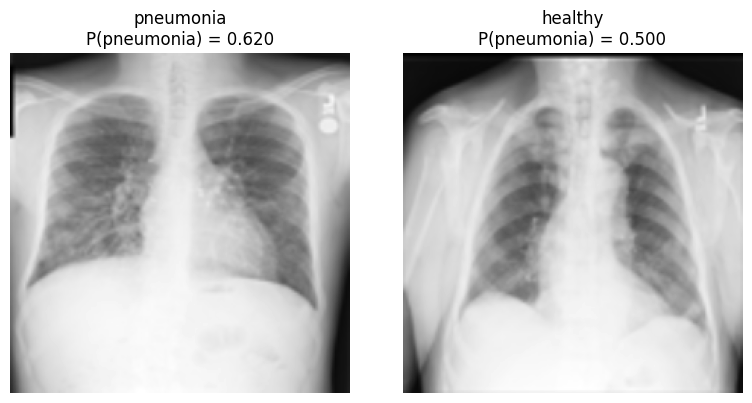

Saved to results/chexnet_sanity_check.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (cls, img) in zip(axes, samples.items()):
    prob = chexnet.predict_pneumonia(img.to(DEVICE)).item()
    ax.imshow(img.squeeze().cpu(), cmap="gray")
    ax.set_title(f"{cls}\nP(pneumonia) = {prob:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "results" / "chexnet_sanity_check.png", dpi=120)
plt.show()
print("Saved to results/chexnet_sanity_check.png")

## 4. Batch inference helper — for use in counterfactual evaluation

In [28]:
from torch.utils.data import DataLoader, TensorDataset

def chexnet_scores(chexnet, images_224: torch.Tensor, batch_size=64) -> torch.Tensor:
    """Run CheXNet over a batch of 224×224 grayscale images.

    Args:
        images_224: (N, 1, 224, 224) float32 in [0, 1]
    Returns:
        probs: (N,) P(pneumonia) for each image
    """
    device = next(chexnet.parameters()).device
    loader = DataLoader(TensorDataset(images_224), batch_size=batch_size)
    probs = []
    with torch.inference_mode():
        for (batch,) in loader:
            probs.append(chexnet.predict_pneumonia(batch.to(device)).cpu())
    return torch.cat(probs)


# Quick smoke test
dummy = torch.rand(4, 1, 224, 224)
scores = chexnet_scores(chexnet, dummy)
print(f"Batch output shape: {scores.shape}  range: [{scores.min():.3f}, {scores.max():.3f}]")

Batch output shape: torch.Size([4])  range: [0.307, 0.344]


## 5. Freeze checkpoint — save eval state dict

Save a clean state dict so other notebooks can reload CheXNet without needing
the raw `pth.tar` format.

In [18]:
frozen_path = PROJECT_ROOT / "models" / "Classifier" / "chexnet_arbiter.pt"
torch.save(chexnet.state_dict(), frozen_path)
print(f"Frozen arbiter saved to {frozen_path}  ({frozen_path.stat().st_size / 1e6:.1f} MB)")

Frozen arbiter saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/models/Classifier/chexnet_arbiter.pt  (28.5 MB)


## 6. Evaluation on the test set

Run CheXNet over all 9 425 test images and compute standard classification metrics.
Images are stored at 128×128 and resized to 224×224 on-the-fly before inference.

In [29]:
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np

sys.path.insert(0, str(PROJECT_ROOT / "utils"))
from metrics import compute_accuracy, compute_roc_auc, compute_confusion_matrix, print_metrics, plot_roc_curve

resize_224 = transforms.Resize((224, 224), antialias=True)

all_scores, all_labels = [], []

chexnet.eval()
loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)

with torch.inference_mode():
    for imgs, labels, _ in loader:
        imgs_224 = torch.stack([resize_224(img) for img in imgs]).to(DEVICE)
        scores = chexnet.predict_pneumonia(imgs_224).cpu()
        all_scores.append(scores)
        all_labels.append(labels[:, 1].float())  # one-hot → pneumonia column

y_scores = torch.cat(all_scores).numpy()
y_true   = torch.cat(all_labels).numpy()

print(f"Test set: {len(y_true)} images  |  pneumonia: {int(y_true.sum())}  |  healthy: {int((1-y_true).sum())}")

Test set: 9021 images  |  pneumonia: 43  |  healthy: 8978


In [30]:
from sklearn.metrics import roc_curve

# --- 1. inference on val set for best threshold ---
val_ds = torch.load(PROJECT_ROOT / "data" / "processed_v2" / "val_dataset.pt", weights_only=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

val_scores, val_labels = [], []
with torch.inference_mode():
    for imgs, labels, _ in val_loader:
        imgs_224 = torch.stack([resize_224(img) for img in imgs]).to(DEVICE)
        val_scores.append(chexnet.predict_pneumonia(imgs_224).cpu())
        val_labels.append(labels[:, 1].float())

val_sc = torch.cat(val_scores).numpy()
val_y  = torch.cat(val_labels).numpy()

# --- 2. Youden's J: maximize TPR - FPR ---
fpr, tpr, thresholds = roc_curve(val_y, val_sc)
best_idx       = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print(f"Best threshold (val): {best_threshold:.4f}")
print(f"  TPR={tpr[best_idx]:.3f}  FPR={fpr[best_idx]:.3f}")

Best threshold (val): 0.3414
  TPR=0.796  FPR=0.385



=== CheXNet on test set (threshold = 0.3414) ===
Accuracy : 0.6296
AUC-ROC  : 0.7423
Confusion matrix (threshold=0.3414328098297119):
  TN=5646  FP=3332
  FN=9  TP=34
ROC curve saved to results/chexnet_roc_curve.png


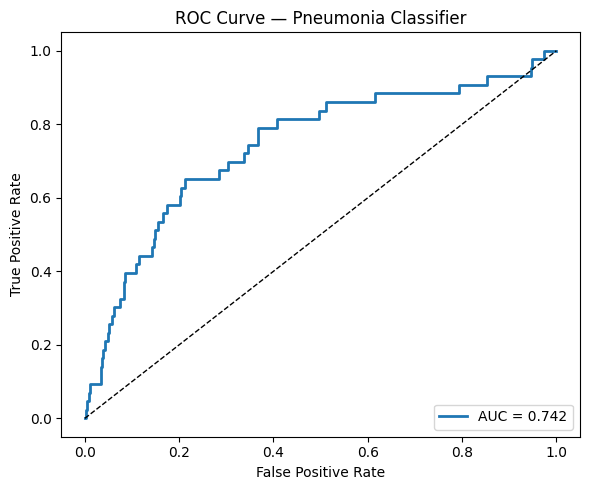

In [33]:
# --- 3. evaluate test set with best threshold ---
print(f"\n=== CheXNet on test set (threshold = {best_threshold:.4f}) ===")
print_metrics(y_true, y_scores, threshold=best_threshold)

results_dir = PROJECT_ROOT / "results"
plot_roc_curve(y_true, y_scores, save_path=results_dir / "chexnet_roc_curve.png")
print("ROC curve saved to results/chexnet_roc_curve.png")

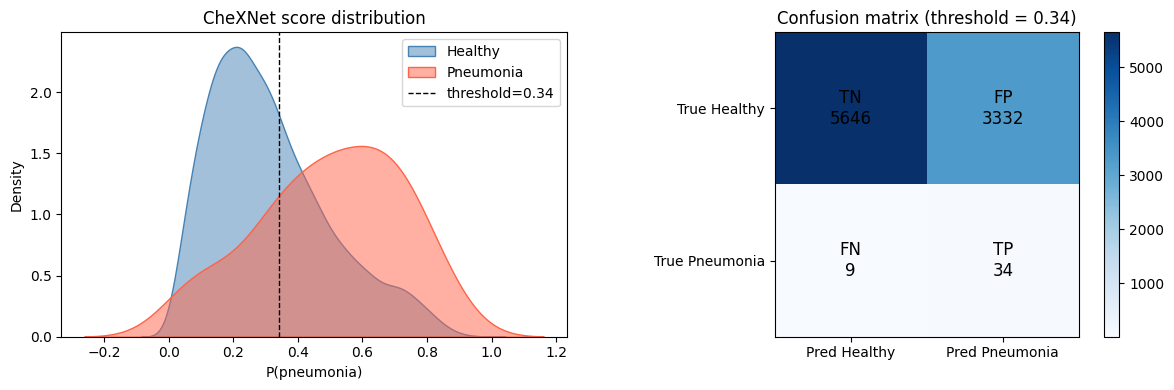

Saved to results/chexnet_evaluation.png


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = compute_confusion_matrix(y_true, y_scores, threshold=best_threshold)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Score distribution ---
ax = axes[0]
sns.kdeplot(y_scores[y_true == 0], ax=ax, fill=True, common_norm=False,
            label="Healthy", color="steelblue", alpha=0.5)
sns.kdeplot(y_scores[y_true == 1], ax=ax, fill=True, common_norm=False,
            label="Pneumonia", color="tomato", alpha=0.5)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1, label=f"threshold={best_threshold:.2f}")
ax.set_xlabel("P(pneumonia)")
ax.set_ylabel("Density")
ax.set_title("CheXNet score distribution")
ax.legend()

# --- Confusion matrix ---
ax = axes[1]
mat = [[tn, fp], [fn, tp]]
labels = [["TN", "FP"], ["FN", "TP"]]
im = ax.imshow(mat, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{mat[i][j]}", ha="center", va="center", fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Healthy", "Pred Pneumonia"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True Healthy", "True Pneumonia"])
ax.set_title(f"Confusion matrix (threshold = {best_threshold:.2f})")
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(results_dir / "chexnet_evaluation.png", dpi=120)
plt.show()
print("Saved to results/chexnet_evaluation.png")